In [ ]:
%load_ext autoreload
%autoreload 2

import sys; sys.path += ['./../']
import numpy as np
from CardamomOT import train_classifier, predict_cell_types, plot_cell_type_proportions
import anndata as ad
import getopt
import scipy
import scanpy as sc
import matplotlib.pyplot as plt

label="cell_type"
stim = 1.0
prior = 1.0

def check_cell_types_full(clf, p, split='train', test=False):

    ### Compare cell type on mRNA
    adata_train_true = ad.read_h5ad(p+f'Data/data_{split}.h5ad')
    adata_train = ad.read_h5ad(p+'cardamomOT/adata_beta_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_sim_train = ad.read_h5ad(p+'cardamomOT/adata_sim_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_theta_train = ad.read_h5ad(p+'cardamomOT/adata_theta_stim{}_prior{}.h5ad'.format(stim, prior))
    if test:
        adata_test_true = ad.read_h5ad(p+'Data/data_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_test = ad.read_h5ad(p+'cardamomOT/adata_beta_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_sim_test = ad.read_h5ad(p+'cardamomOT/adata_sim_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_theta_test = ad.read_h5ad(p+'cardamomOT/adata_theta_test_stim{}_prior{}.h5ad'.format(stim, prior))

    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_sim_train = predict_cell_types(adata_sim_train, clf, label_key=label)
    adata_theta_train = predict_cell_types(adata_theta_train, clf, label_key=label)

    if test:
        adata_test = predict_cell_types(adata_test, clf, label_key=label)
        adata_sim_test = predict_cell_types(adata_sim_test, clf, label_key=label)
        adata_theta_test = predict_cell_types(adata_theta_test, clf, label_key=label)

    adata_train.write(p+'cardamomOT/adata_beta_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_sim_train.write(p+'cardamomOT/adata_sim_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_theta_train.write(p+'cardamomOT/adata_theta_stim{}_prior{}.h5ad'.format(stim, prior))
    if test:
        adata_test.write(p+'cardamomOT/adata_beta_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_sim_test.write(p+'cardamomOT/adata_sim_test_stim{}_prior{}.h5ad'.format(stim, prior))
        adata_theta_test.write(p+'cardamomOT/adata_theta_test_stim{}_prior{}.h5ad'.format(stim, prior))

    cmap_cat = plt.get_cmap('Dark2')
    cats = adata_train.obs["cell_type"].astype(str).unique().tolist()
    colors = [cmap_cat(i % 20) for i in range(len(cats))]
    
    if not test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_train, adata_theta_train, adata_sim_train],
        labels=["data", "NB mixture", "modes", "sim"],
        label_key=label, colors=colors
        )

    if test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_test_true, adata_train, adata_theta_train, adata_sim_train, adata_test, adata_theta_test,
                    adata_sim_test],
        labels=["train", "test", "mixture train", "theta train", "sim train", "mixture test", "theta test", "sim test"],
        )

def check_cell_types_mixture(clf, p, split='train', test=False):

    ### Compare cell type on mRNA
    adata_train_true = ad.read_h5ad(p+'Data/data_{}.h5ad'.format(split))
    adata_train = ad.read_h5ad(p+'cardamomOT/adata_beta.h5ad')
    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_train.write(p+'cardamomOT/adata_beta.h5ad'.format(stim, prior))
    # print(adata_train_true.obs['cell_type'].values)
    # print(adata_train.obs['cell_type'].values)

    if not test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_train],
        labels=["train", "mixture train"],
        label_key=label
        )

def check_cell_types_init(clf, p, test=False):

    ### Compare cell type on mRNA
    adata_train_true = ad.read_h5ad(p+'Data/data_train.h5ad')
    adata_full = ad.read_h5ad(p+'Data/data_full.h5ad'.format(stim, prior))
    adata_full = predict_cell_types(adata_full, clf, label_key=label)
    adata_full.write(p+'cardamomOT/adata_full.h5ad')

    if not test:
        plot_cell_type_proportions(
        adatas=[adata_train_true, adata_full],
        labels=["train", "full"],
        label_key=label
        )




def check_cell_types_binary(clf, p):
    ### Compare cell type on binary vectors
    adata_train = ad.read_h5ad(p+'cardamomOT/adata_beta.h5ad')
    adata_test = ad.read_h5ad(p+'cardamomOT/adata_beta_test.h5ad')
    adata_sim_train = ad.read_h5ad(p+'cardamomOT/adata_sim.h5ad')
    adata_sim_test = ad.read_h5ad(p+'cardamomOT/adata_sim_test.h5ad')
    adata_theta_train = ad.read_h5ad(p+'cardamomOT/adata_theta.h5ad')
    adata_theta_test = ad.read_h5ad(p+'cardamomOT/adata_theta_test.h5ad')

    vect_kon_train = np.load(p + 'cardamomOT/data_kon_beta.npy')
    vect_kon_test = np.load(p + 'cardamomOT/data_kon_beta_test.npy')
    vect_kon_theta_train = np.load(p + 'cardamomOT/data_kon_theta.npy')
    vect_kon_theta_test = np.load(p + 'cardamomOT/data_kon_theta_test.npy')
    vect_kon_sim_train = np.load(p + 'cardamomOT/data_kon_simul.npy')
    vect_kon_sim_test = np.load(p + 'cardamomOT/data_kon_simul_test.npy')

    print(np.mean(vect_kon_theta_train), np.mean(vect_kon_train), np.mean(vect_kon_sim_train))

    adata_train.X = scipy.sparse.csr_matrix(vect_kon_train[:, 1:])
    adata_test.X = scipy.sparse.csr_matrix(vect_kon_test[:, 1:])
    adata_theta_train.X = scipy.sparse.csr_matrix(vect_kon_theta_train[:, 1:])
    adata_theta_test.X = scipy.sparse.csr_matrix(vect_kon_theta_test[:, 1:])
    adata_sim_test.X = scipy.sparse.csr_matrix(vect_kon_sim_test[:, 1:])
    adata_sim_train.X = scipy.sparse.csr_matrix(vect_kon_sim_train[:, 1:])

    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_test = predict_cell_types(adata_test, clf, label_key=label)
    adata_sim_train = predict_cell_types(adata_sim_train, clf, label_key=label)
    adata_sim_test = predict_cell_types(adata_sim_test, clf,  label_key=label)
    adata_theta_train = predict_cell_types(adata_theta_train, clf, label_key=label)
    adata_theta_test = predict_cell_types(adata_theta_test, clf, label_key=label)

    adata_train.write(p+'cardamomOT/adata_beta.h5ad')
    adata_sim_train.write(p+'cardamomOT/adata_sim.h5ad')
    adata_theta_train.write(p+'cardamomOT/adata_theta.h5ad')
    adata_test.write(p+'cardamomOT/adata_beta_test.h5ad')
    adata_sim_test.write(p+'cardamomOT/adata_sim_test.h5ad')
    adata_theta_test.write(p+'cardamomOT/adata_theta_test.h5ad')

    plot_cell_type_proportions(
    adatas=[adata_train, adata_test, adata_theta_train, adata_sim_train, adata_theta_test,
            adata_sim_test],
    labels=["train", "test", "theta train", "sim train", "theta test", "sim test"],
    label_key=label
    )

2026-03-10 12:21:08,182 | numexpr.utils | INFO | NumExpr defaulting to 12 threads.


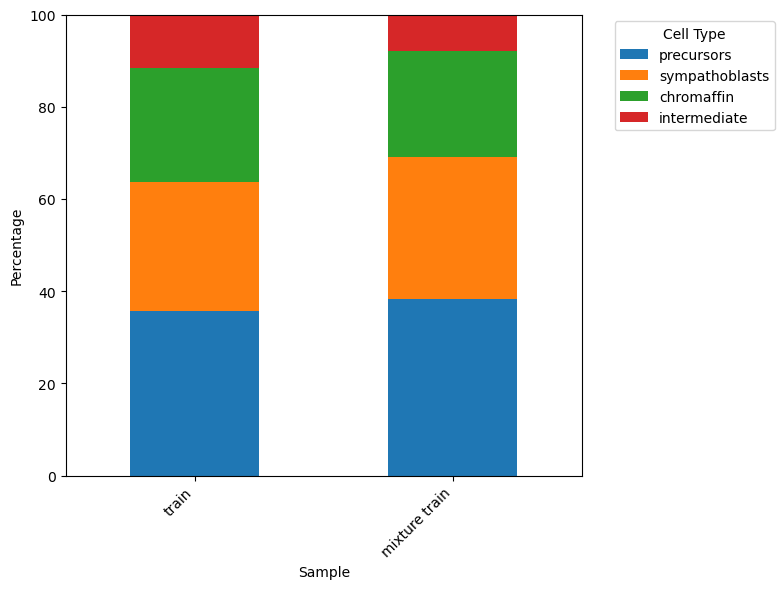

cell_type      precursors  sympathoblasts  chromaffin  intermediate
train           35.722222       28.055556   24.722222     11.500000
mixture train   38.277778       30.777778   23.111111      7.833333


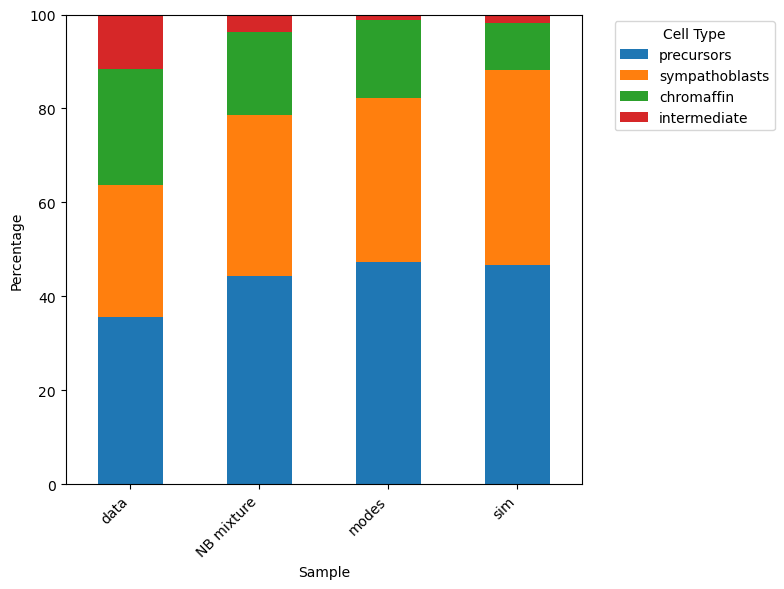

cell_type   precursors  sympathoblasts  chromaffin  intermediate
data         35.722222       28.055556   24.722222     11.500000
NB mixture   44.444444       34.277778   17.500000      3.777778
modes        47.388889       34.944444   16.444444      1.222222
sim          46.777778       41.500000    9.888889      1.833333


In [11]:
p = './../collaborations/Data_Olivier/' 

adata_full = ad.read_h5ad(p+'Data/data_full.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p, split='full')
check_cell_types_full(clf, p, split='full')

AnnData object with n_obs × n_vars = 2449 × 40
    obs: 'time', 'cell_type'
    var: 'd0', 'd1'


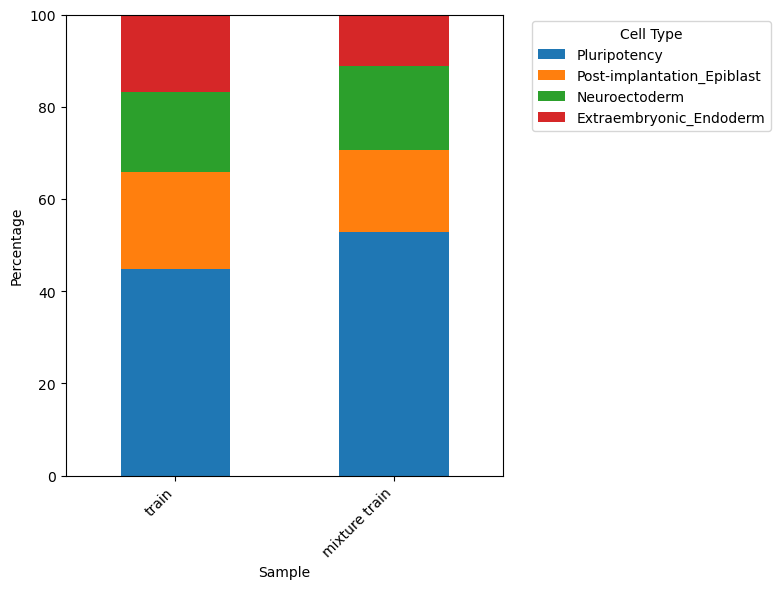

cell_type      Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
train             44.712127                   21.069824      17.517354   
mixture train     52.878726                   17.844018      18.170682   

cell_type      Extraembryonic_Endoderm  
train                        16.700694  
mixture train                11.106574  


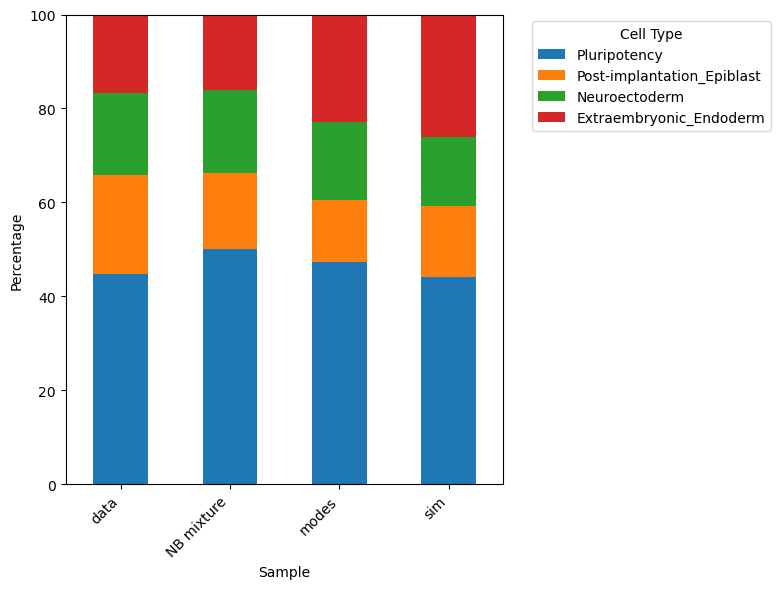

cell_type   Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
data           44.712127                   21.069824      17.517354   
NB mixture     50.000000                   16.269841      17.676768   
modes          47.438672                   13.131313      16.594517   
sim            44.191919                   14.971140      14.754690   

cell_type   Extraembryonic_Endoderm  
data                      16.700694  
NB mixture                16.053391  
modes                     22.835498  
sim                       26.082251  


In [3]:
p = './../experimental_datasets/Semrau/'

adata_full = ad.read_h5ad(p+'Data/data_full.h5ad')
print(adata_full)
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p, split="full")
check_cell_types_full(clf, p, split="full")

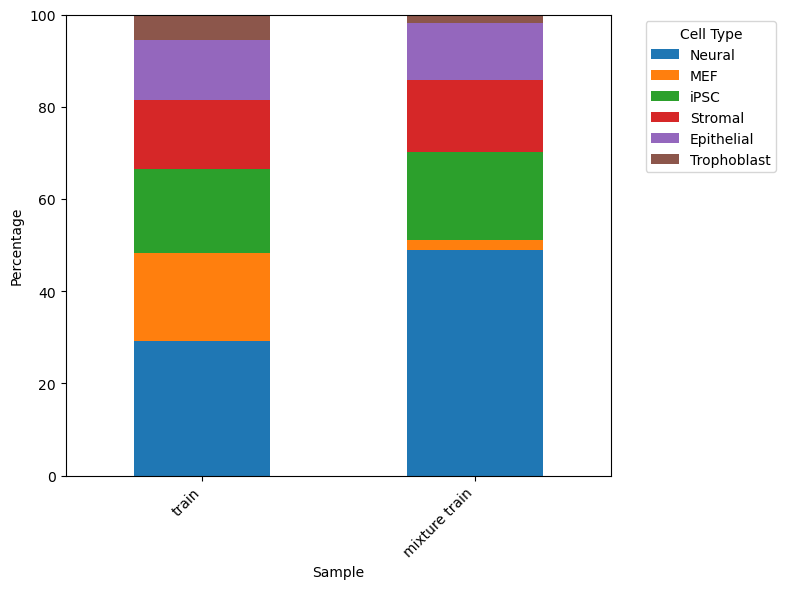

cell_type         Neural        MEF       iPSC    Stromal  Epithelial  \
train          29.168033  19.025765  18.337376  14.980660   12.922048   
mixture train  48.901855   2.235626  19.071658  15.596932   12.404117   

cell_type      Trophoblast  
train             5.566118  
mixture train     1.789812  


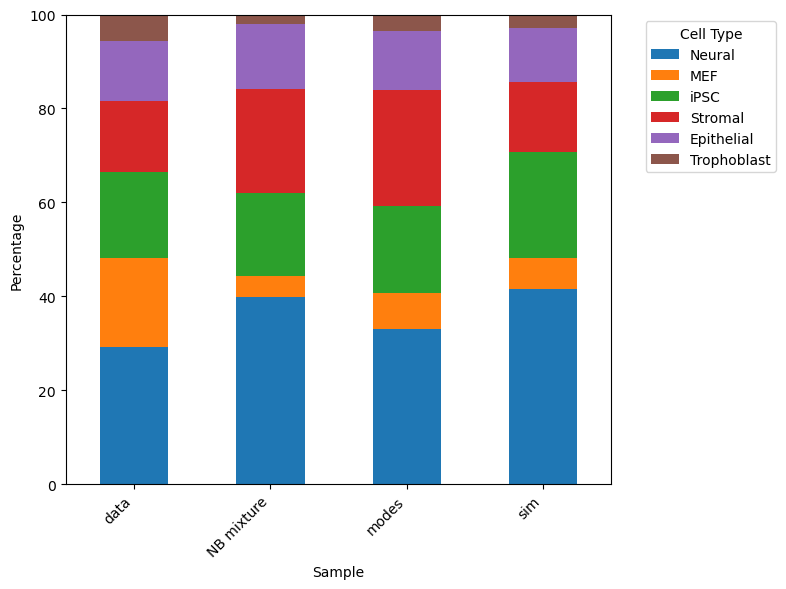

cell_type      Neural        MEF       iPSC    Stromal  Epithelial  \
data        29.168033  19.025765  18.337376  14.980660   12.922048   
NB mixture  39.957002   4.448929  17.681643  22.042822   13.838189   
modes       33.182696   7.647420  18.528431  24.578800   12.478062   
sim         41.672517   6.576869  22.437697  14.939452   11.451386   

cell_type   Trophoblast  
data           5.566118  
NB mixture     2.031415  
modes          3.584591  
sim            2.922078  


In [13]:
p = './../collaborations/Schiebinger/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
sc.pp.log1p(adata_full)
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p)
check_cell_types_full(clf, p)